start->topic-> llm outline -> blog(topic+outline) ->end

In [12]:
from langgraph.graph import StateGraph,START,END
from langchain_groq import ChatGroq
from typing import TypedDict
from dotenv import load_dotenv
import os

In [13]:
load_dotenv()
model = ChatGroq(
    groq_api_key=os.getenv("GROQ_API_KEY") ,
    model="llama-3.3-70b-versatile"
)

In [14]:
class BlogState(TypedDict):
    topic: str
    outline: str
    content: str

In [15]:
def gen_outline(state:BlogState) -> BlogState:

    topic=state['topic']

    prompt=f"generate proper outline for this blog topic - {topic}"
    outline=model.invoke(prompt).content

    #update state
    state['outline']=outline

    return state


In [16]:
def create_blog(state:BlogState)-> BlogState:

    topic=state['topic']
    outline=state['outline']

    prompt=f"write a detailed blog on topic - {topic} using the following outline \n {outline}"

    content=model.invoke(prompt).content

    state['content']=content

    return state

In [17]:
graph=StateGraph(BlogState)

graph.add_node('gen_outline',gen_outline)
graph.add_node('create_blog',create_blog)

graph.add_edge(START,'gen_outline')
graph.add_edge('gen_outline','create_blog')
graph.add_edge('create_blog',END)

workflow=graph.compile()


In [20]:
initial_state={'topic':'impact of AI on jobs in india'}

final_state=workflow.invoke(initial_state)

print(final_state)


{'topic': 'impact of AI on jobs in india', 'outline': 'Here is a suggested outline for the blog topic "Impact of AI on Jobs in India":\n\n**I. Introduction**\n\n* Briefly introduce the topic of Artificial Intelligence (AI) and its growing presence in the Indian job market\n* Mention the purpose of the blog post: to explore the impact of AI on jobs in India\n* Provide an overview of the main points that will be discussed in the post\n\n**II. Current State of AI in India**\n\n* Discuss the current state of AI adoption in India, including:\n\t+ Industries that are already using AI (e.g. IT, healthcare, finance)\n\t+ Types of AI being used (e.g. machine learning, natural language processing)\n\t+ Government initiatives to promote AI development and adoption\n\n**III. Positive Impact of AI on Jobs in India**\n\n* Discuss the potential benefits of AI on the Indian job market, including:\n\t+ Job creation in AI-related fields (e.g. data science, machine learning engineering)\n\t+ Increased pr

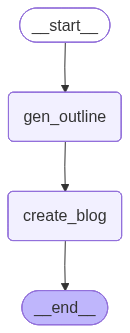

In [19]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())